In [4]:
#1.

import pandas as pd
import numpy as np

transactions = pd.DataFrame({
    "customer_id": np.repeat([1,2,3,4,5], 4),
    "purchase_amount": np.random.randint(100, 500, 20),
    "date": pd.date_range("2026-01-01", periods=20, freq="7D")

})
transactions.to_csv("transactions.csv", index=False)

df = pd.read_csv("transactions.csv")
df['date'] = pd.to_datetime(df['date'])    # Convert date column into date format
df['month'] = df['date'].dt.to_period('M')  # Create a new column for month

monthly_avg = df.groupby(['customer_id', 'month'])['purchase_amount'].mean().reset_index()
print(monthly_avg)


   customer_id    month  purchase_amount
0            1  2026-01       309.000000
1            2  2026-01       133.000000
2            2  2026-02       366.333333
3            3  2026-02       355.000000
4            3  2026-03       173.333333
5            4  2026-03       129.000000
6            4  2026-04       293.000000
7            5  2026-04       338.000000
8            5  2026-05       277.000000


In [6]:
#2.
employees = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie", "David","Eva"],
    "age": [25, np.nan, 30, np.nan, 40],
    "salary": [50000, 60000, np.nan, 70000, np.nan],
    "department": ["HR", "IT", "Finance", "IT", "Sales"]
})

employees.to_csv("employees.csv", index=False)

employees = pd.read_csv("employees.csv")
print("Missing values:\n", employees.isnull().sum())

employees['age'].fillna(employees['age'].mean(), inplace=True)
employees['salary'].fillna(employees['salary'].mean(), inplace=True)

print(employees)

Missing values:
 name          0
age           2
salary        2
department    0
dtype: int64
      name        age   salary department
0    Alice  25.000000  50000.0         HR
1      Bob  31.666667  60000.0         IT
2  Charlie  30.000000  60000.0    Finance
3    David  31.666667  70000.0         IT
4      Eva  40.000000  60000.0      Sales


/tmp/ipykernel_993/3237729666.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  employees['age'].fillna(employees['age'].mean(), inplace=True)
/tmp/ipykernel_993/3237729666.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [7]:
#3.
# using same data set 'employees'

filtered = employees[(employees['department']=='IT') & (employees['salary']>60000)]
sorted_df = filtered.sort_values(by='salary', ascending=False)
print(sorted_df)


    name        age   salary department
3  David  31.666667  70000.0         IT


In [9]:
#4.
stocks = pd.DataFrame({
    "date": pd.date_range("2026-01-01", periods=30),
    "price": np.random.randint(100, 200, 30)
})

stocks.to_csv("stocks.csv", index=False)

stocks = pd.read_csv("stocks.csv")
prices = stocks['price']

print("Mean:", np.mean(prices))
print("Median:", np.median(prices))
print("Std Dev:", np.std(prices))

Mean: 149.5
Median: 149.5
Std Dev: 28.753840323221755


In [14]:
#5.
sales = pd.DataFrame({
    "region": np.random.choice(["North", "South", "East", "West"], 20),
    "product": np.random.choice(["A", "B", "C"], 20),
    "sales":np.random.randint(1000, 5000, 20),
    "category": np.random.choice(["Electronics", "Clothing", "Food"], 20),
    "advertising_budget": np.random.randint(500, 2000, 20)
})
sales.to_csv("sales.csv", index=False)

sales = pd.read_csv("sales.csv")

pivot = pd.pivot_table(sales, values='sales', index='region', columns='product', aggfunc='sum')
print(pivot)

product        A       B       C
region                          
East      6698.0     NaN  9332.0
North    10198.0  4357.0  3854.0
South        NaN  6583.0  3959.0
West      5793.0  3801.0  6739.0


/tmp/ipykernel_993/3355658459.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "month": pd.date_range("2026-01-01", periods=12, freq="M"),


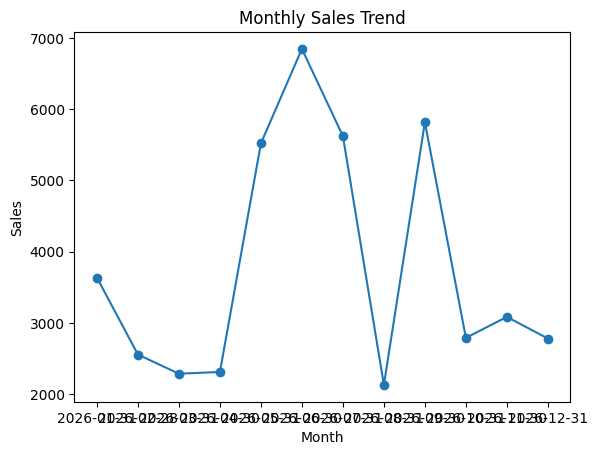

In [16]:
#6.
import matplotlib.pyplot as plt

monthly_sales = pd.DataFrame({
    "month": pd.date_range("2026-01-01", periods=12, freq="M"),
    "sales": np.random.randint(2000, 8000, 12)
})
monthly_sales.to_csv("monthly_sales.csv", index=False)

monthly_sales = pd.read_csv("monthly_sales.csv")
plt.plot(monthly_sales['month'], monthly_sales['sales'], marker='o')
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.show()


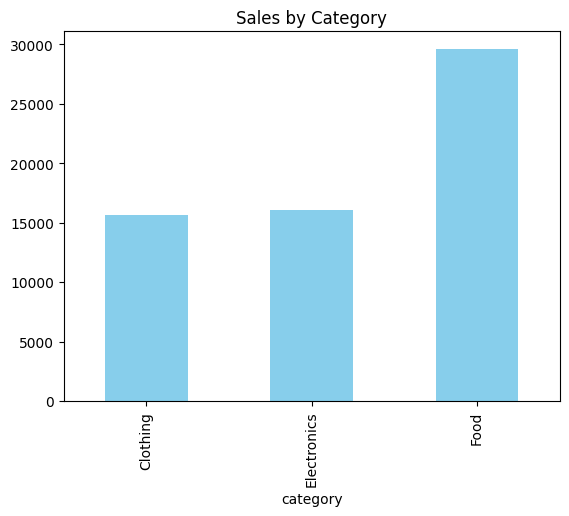

In [17]:
#7.
category_sales = sales.groupby('category')['sales'].sum()
category_sales.plot(kind='bar', color='skyblue')
plt.title("Sales by Category")
plt.show()

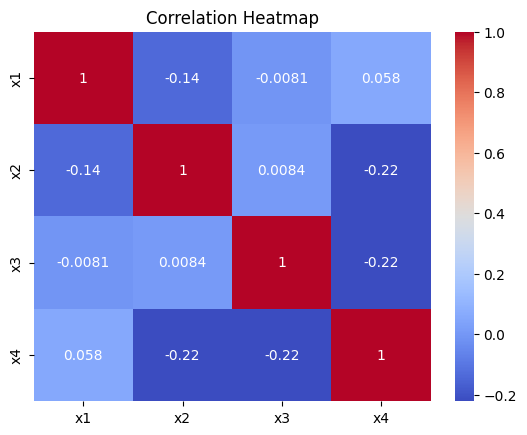

In [18]:
#8.
import seaborn as sns

corr_data = pd.DataFrame({
    "x1": np.random.randint(10, 100, 50),
    "x2": np.random.randint(20, 200, 50),
    "x3": np.random.randint(5, 50, 50),
    "x4": np.random.randint(100, 500, 50)
})
corr_data.to_csv("corr_data.csv", index=False)

corr_data = pd.read_csv("corr_data.csv")
corr = corr_data.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

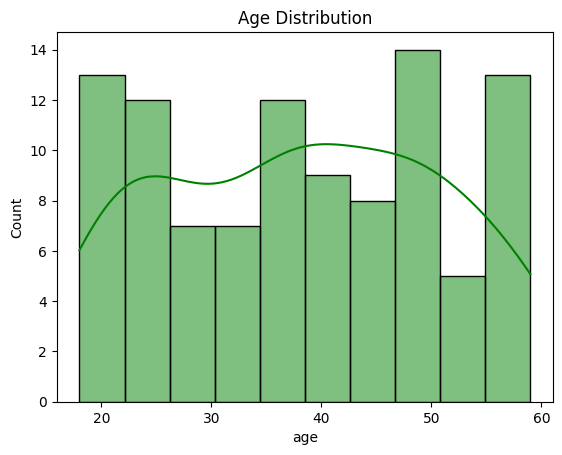

In [19]:
#9.
ages = pd.DataFrame({
    "age": np.random.randint(18, 60, 100)
})
ages.to_csv("ages.csv", index=False)

ages = pd.read_csv("ages.csv")
sns.histplot(ages['age'], bins=10, kde=True, color='green')
plt.title("Age Distribution")
plt.show()

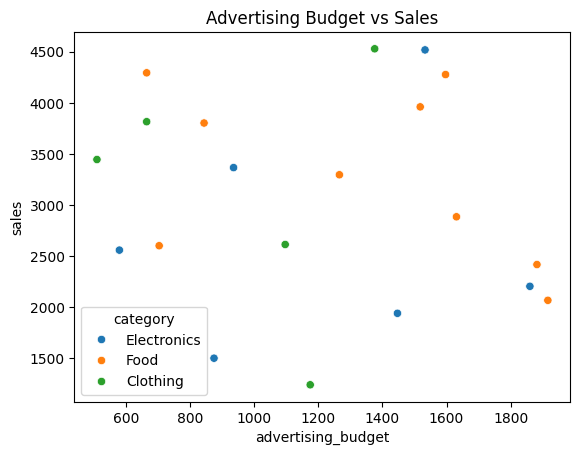

In [20]:
#10.
sns.scatterplot(x='advertising_budget', y='sales', data=sales, hue='category')
plt.title("Advertising Budget vs Sales")
plt.show()